# Machine Learning Models

### Importing Data, Cleaning and Feature Engineering

In [8]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import ast
import seaborn as sns
import matplotlib.pyplot as plt 

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error


df = pd.read_csv('../data/movies.csv')

threshold = df["revenue"].quantile(0.75)

df["success"] = (df["revenue"] >= threshold).astype(int)
# print(df.iloc[3000]["genres"])

Genre One-Hot Encoding

In [9]:
# One-Hot Encoding

df["genres_parsed"] = df["genres"].apply(ast.literal_eval)
df["genre_names"] = df["genres_parsed"].apply(lambda x: [d["name"] for d in x])

mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df["genre_names"])

encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, encoded_df], axis=1)
# print(df.iloc[3000]["genre_names"])

Top Actors in Movie

In [10]:
cols = df.columns.to_list()
# print(cols)

from collections import Counter

df["cast_parsed"] = df["cast"].apply(ast.literal_eval)
df["actor_names"] = df["cast_parsed"].apply(lambda x: [d["name"] for d in x])
all_actors = [actor for sublist in df["actor_names"] for actor in sublist]

actor_counts = Counter(all_actors)
top_10_actors = actor_counts.most_common(10)
# print(top_10_actors)


Top 10 Actors

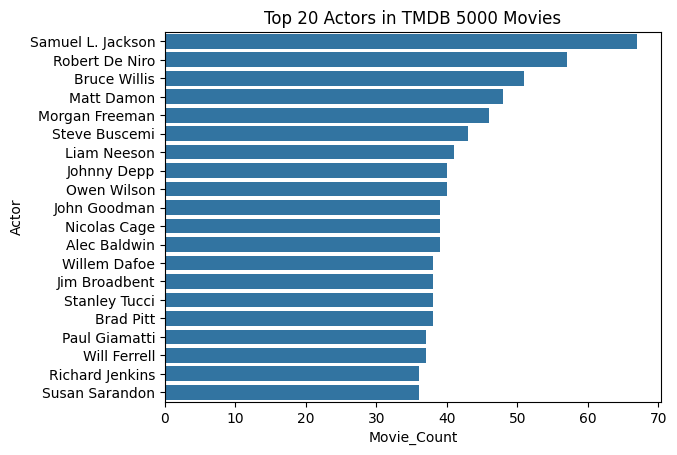

In [11]:
top_actors_df = pd.DataFrame(actor_counts.most_common(20), columns=["Actor", "Movie_Count"])

sns.barplot(data=top_actors_df, x="Movie_Count", y="Actor")
plt.title("Top 20 Actors in TMDB 5000 Movies")
plt.show()

In [12]:
top_20_actors = [name[0] for name in actor_counts.most_common(20)]
df["num_top_actors"] = df["actor_names"].apply(
    lambda actors: sum(1 for actor in actors if actor in top_20_actors)
)
# print(df.iloc[1]["num_top_actors"])
# print(df["num_top_actors"])
# print(df.iloc[3]["cast"])
# df[["original_title", "actor_names", "num_top_actors"]].head()
# print(df.iloc[3]["actor_names"])

In [13]:
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year

features_of_interest = ["budget", "release_month", "release_year", "num_top_actors"] # predict revenue

### Model Comparison, Cross Validation, Metrics, Feature Importance

Three classification models were trained to predict whether a movie would be in the top 25% of revenue.

Models evaluated:

• Logistic Regression – a simple linear baseline model used for interpretability and benchmarking.  
• Random Forest Classifier – an ensemble model capable of capturing nonlinear relationships and feature interactions.  
• XGBoost Classifier – a gradient boosting model known for strong predictive performance on structured tabular datasets.

Comparing multiple models helps determine whether more complex algorithms significantly improve predictive performance over simpler approaches.



Logistic Regression
CV ROC-AUC Mean: 0.882019513223144
CV ROC-AUC Std: 0.014573913967809988

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       696
           1       0.78      0.54      0.64       266

    accuracy                           0.83       962
   macro avg       0.81      0.74      0.76       962
weighted avg       0.82      0.83      0.82       962

ROC-AUC: 0.8938348025235503


/var/folders/_v/0d3shdb10bvb1sp09bm59gzw0000gn/T/ipykernel_77418/351560268.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


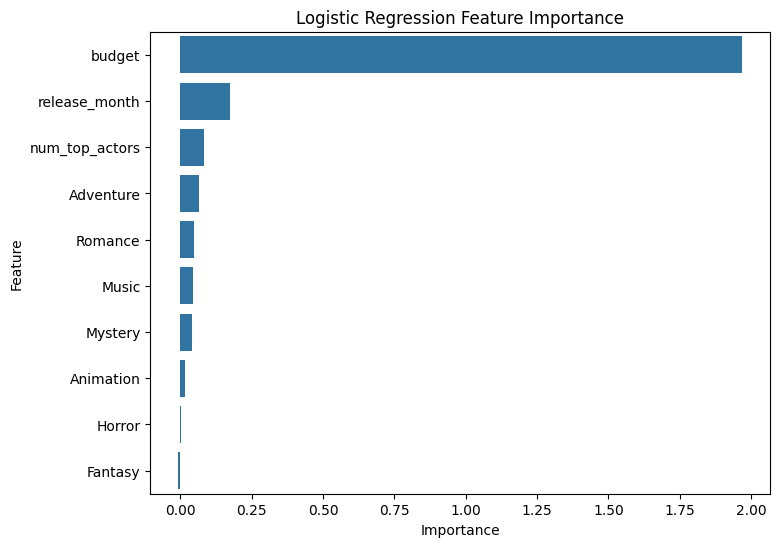


Random Forest
CV ROC-AUC Mean: 0.8856791076318062
CV ROC-AUC Std: 0.015168687449325766

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       696
           1       0.75      0.60      0.67       266

    accuracy                           0.84       962
   macro avg       0.81      0.76      0.78       962
weighted avg       0.83      0.84      0.83       962

ROC-AUC: 0.8945180840031113


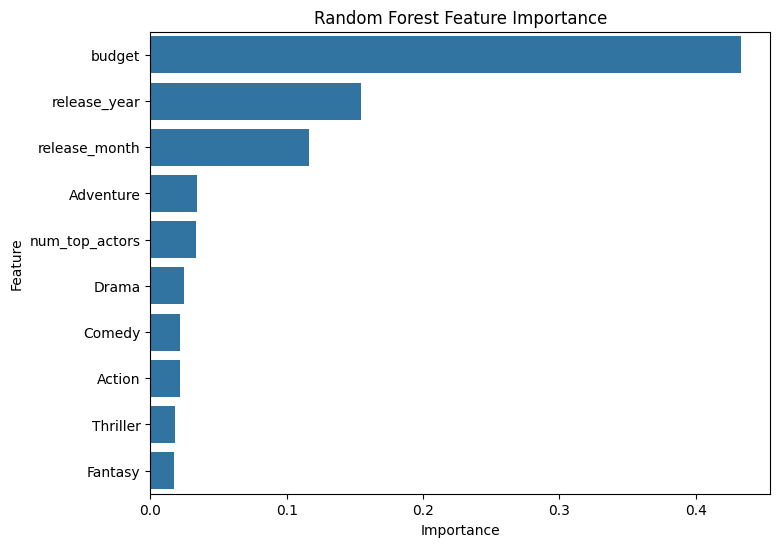


XGBoost


/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [20:39:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [20:39:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [20:39:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [20:39:22] WARN

CV ROC-AUC Mean: 0.8918396120736676
CV ROC-AUC Std: 0.015881470557911725


/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [20:39:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       696
           1       0.74      0.60      0.66       266

    accuracy                           0.83       962
   macro avg       0.80      0.76      0.78       962
weighted avg       0.83      0.83      0.83       962

ROC-AUC: 0.8967515772189094


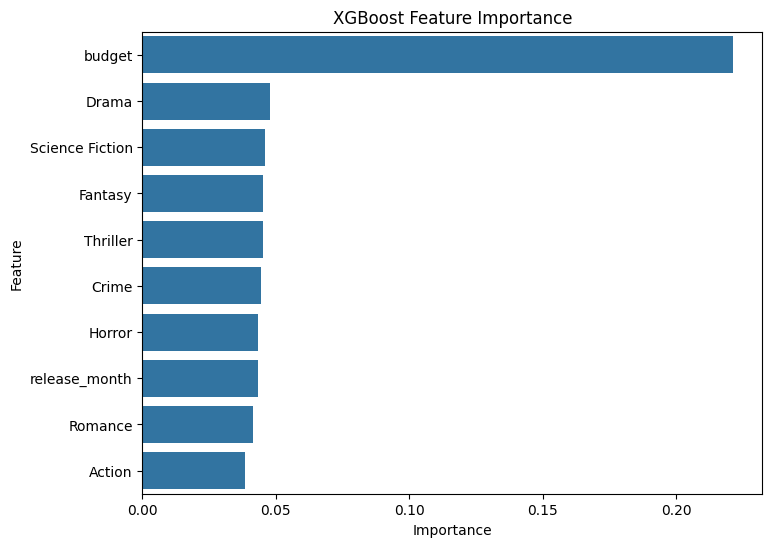

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
}

genres = list(mlb.classes_)

features_of_interest = ["budget", "release_month", "release_year", "num_top_actors"] + genres
df.fillna(0, inplace=True)

X = df[features_of_interest]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, model in models.items():
    print(f"\n{name}")

    ###### CROSS VALIDATION ###### 
    if name == "Logistic Regression":
        cv_scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="roc_auc"
        )
    else:
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="roc_auc"
        )

    print("CV ROC-AUC Mean:", cv_scores.mean())
    print("CV ROC-AUC Std:", cv_scores.std())


    ###### TRAINING MODEL ###### 
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, probs)

    print(f"\n{name}")
    print(classification_report(y_test, predictions))
    print("ROC-AUC:", auc)


    ###### FEATURE IMPORTANCE ###### 
    if name == "Logistic Regression":

        importances = model.coef_[0]

    else:

        importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
    plt.title(f"{name} Feature Importance")
    plt.show()